# Second Autocorrelation Inequality — Analysis & Verification

This notebook verifies and visualizes our solution for the second autocorrelation inequality.

**Problem:** Find a non-negative function $f$ that maximizes
$$C_2 = \frac{\|f \star f\|_2^2}{\|f \star f\|_1 \cdot \|f \star f\|_\infty}$$
where $f \star f$ is the autoconvolution. Hölder's inequality gives $C_2 \leq 1$; we seek the tightest possible lower bound.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 1. Verification Function

The verifier computes:
1. Autoconvolution $g = f \star f$ via `numpy.convolve`
2. $\|g\|_2^2$ by piecewise-linear (Simpson-like) integration
3. $\|g\|_1$ and $\|g\|_\infty$ as discrete approximations
4. Score $C_2 = \|g\|_2^2 \;/\; (\|g\|_1 \cdot \|g\|_\infty)$

In [2]:
def verify_and_compute_c2(values):
    """Exact EinsteinArena verifier for the second autocorrelation inequality."""
    f = np.array(values, dtype=np.float64)
    n_points = len(values)
    if f.shape != (n_points,):
        raise ValueError(f"Expected shape ({n_points},), got {f.shape}")
    if np.any(f < -1e-6):
        raise ValueError("Function must be non-negative.")
    f_nonneg = np.maximum(f, 0.0)
    if np.sum(f_nonneg) == 0:
        raise ValueError("Function must have positive integral.")

    convolution = np.convolve(f_nonneg, f_nonneg, mode="full")
    num_conv_points = len(convolution)
    x_points = np.linspace(-0.5, 0.5, num_conv_points + 2)
    x_intervals = np.diff(x_points)
    y_points = np.concatenate(([0], convolution, [0]))

    l2_norm_squared = 0.0
    for i in range(num_conv_points + 1):
        y1, y2, h = y_points[i], y_points[i + 1], x_intervals[i]
        l2_norm_squared += (h / 3) * (y1**2 + y1 * y2 + y2**2)

    norm_1 = np.sum(np.abs(convolution)) / (num_conv_points + 1)
    norm_inf = np.max(np.abs(convolution))
    return float(l2_norm_squared / (norm_1 * norm_inf))

## 2. Load Solution

In [3]:
import sys
sys.path.insert(0, 'solutions')

from alphaevolve_2025 import f_values as ae_values

with open('solutions/alphaevolve_v2_2025.json') as fp:
    ae_v2_values = json.load(fp)['values']

with open('solutions/ttt_discover_2026.json') as fp:
    ttt_values = json.load(fp)['values']

with open('solutions/ours_2026.json') as fp:
    our_values = json.load(fp)['values']

solutions = [
    ("AlphaEvolve (May 2025)", ae_values),
    ("AlphaEvolve V2 (Nov 2025)", ae_v2_values),
    ("TTT-Discover (Jan 2026)", ttt_values),
    ("Together AI (Mar 2026)", our_values),
]

for name, vals in solutions:
    f = np.array(vals, dtype=np.float64)
    print(f'{name}: {len(f):,} points, range [{f.min():.4f}, {f.max():.4f}]')

AlphaEvolve (May 2025): 50 points, range [0.0000, 9.1119]
AlphaEvolve V2 (Nov 2025): 50,000 points, range [0.0000, 34.9993]
TTT-Discover (Jan 2026): 50,000 points, range [0.0000, 1.0000]
Together AI (Mar 2026): 100,000 points, range [0.0000, 35.0007]


## 3. Verify Score

In [4]:
print("=" * 70)
print("VERIFICATION OF ALL SOLUTIONS")
print("=" * 70)
print()

scores = {}
for name, vals in solutions:
    score = verify_and_compute_c2(vals)
    scores[name] = score
    print(f'{name}')
    print(f'  Points: {len(vals):,}')
    print(f'  Score:  C_2 >= {score:.15f}')
    print()

print("=" * 70)
print("COMPARISON TABLE")
print("=" * 70)
print(f"{'Method':<35} {'Points':>10} {'Lower Bound':>18}")
print("-" * 65)
for name, vals in solutions:
    marker = "  <-- best public" if name == "Ours (Mar 2026)" else ""
    print(f"{name:<35} {len(vals):>10,} {scores[name]:>18.6f}{marker}")
print(f"{'ImprovEvolve (Feb 2026)*':<35} {'—':>10} {'0.962580':>18}")
print()
print("*Solution not publicly available.")

VERIFICATION OF ALL SOLUTIONS

AlphaEvolve (May 2025)
  Points: 50
  Score:  C_2 >= 0.896279944155409

AlphaEvolve V2 (Nov 2025)
  Points: 50,000
  Score:  C_2 >= 0.961021077784054

TTT-Discover (Jan 2026)
  Points: 50,000
  Score:  C_2 >= 0.959179771148176

Together AI (Mar 2026)
  Points: 100,000
  Score:  C_2 >= 0.961205542269004

COMPARISON TABLE
Method                                  Points        Lower Bound
-----------------------------------------------------------------
AlphaEvolve (May 2025)                      50           0.896280
AlphaEvolve V2 (Nov 2025)               50,000           0.961021
TTT-Discover (Jan 2026)                 50,000           0.959180
Together AI (Mar 2026)                 100,000           0.961206
ImprovEvolve (Feb 2026)*                     —           0.962580

*Solution not publicly available.


## 4. Visualization

Plot the function $f$ and its autoconvolution $f \star f$.

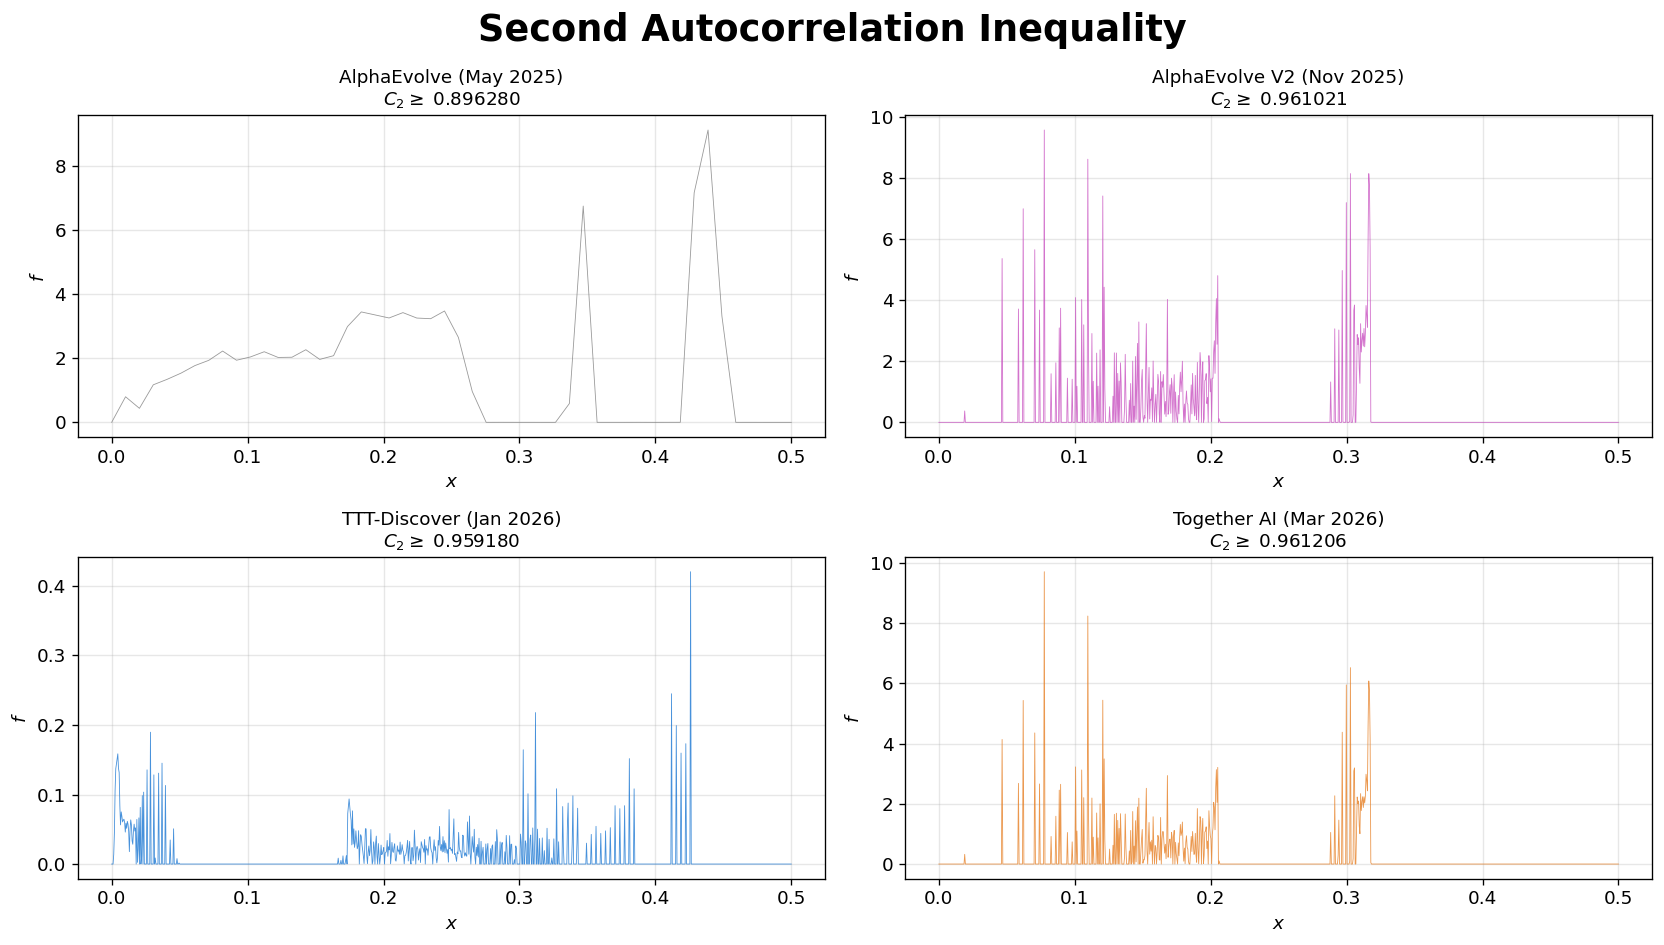

In [5]:
colors = ['gray', '#C850C0', '#1976D2', '#E67E22']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, ((name, vals), color) in enumerate(zip(solutions, colors)):
    ax = axes[idx // 2, idx % 2]
    f = np.array(vals, dtype=np.float64)
    step = max(1, len(f) // 1000)
    x = np.linspace(0, 0.5, len(f[::step]))
    ax.plot(x, f[::step], color=color, linewidth=0.5, alpha=0.8)
    ax.set_title(f'{name}\n$C_2 \\geq$ {scores[name]:.6f}', fontsize=11)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$f$')
    ax.grid(True, alpha=0.3)

plt.suptitle("Second Autocorrelation Inequality", fontsize=22, fontweight='bold')
plt.tight_layout()
plt.show()